# AG-HYPOPT · Trial 14

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Thirteen trials. Best: **trial_13** `cvm_fwhm` **0.0733** (sw 0.1910); the family's mapped basin is sw
0.1816 -> 0.0791, 0.1910 -> 0.0733, 0.1956 -> 0.0760, 0.2074 -> 0.0764, 0.2345 -> 0.0777 - a flat
basin near sw ~0.19-0.20, ~0.007 under the KDE control (0.080328). At the winning sw no other family
beats the control (`kde` 0.0830, `w1_2d` 0.0849, `w1_fwhm` 0.0923, `energy_2d` 0.1021, `mmd_2d` 0.1833).
So the answer to the campaign question is already clear: `cvm_fwhm` is the winning loss form. Phase
`trials` (13/5), EI now concentrated on the `cvm_fwhm` basin. No divergences.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_14'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (13/5 trials)
ID |     ei | params
 1 | 2.6081 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.18240844677969212}
 2 | 3.4292 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.20241228805252337}
 3 | 3.4549 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.20119098136320904}
 4 | 3.5830 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.19084788455130242}
 5 | 3.6072 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.19499926094772702}
 6 | 0.6311 | {"loss_family": "w1_fwhm", "sigma_weight": 0.6501941808471887}
 7 | 3.4790 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.20029200779698972}
 8 | 3.5561 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.19765114031373124}
 9 |      - | {"loss_family": "energy_2d", "sigma_weight": 0.030820231403132725}
10 |      - | {"loss_family": "w1_fwhm", "sigma_weight": 0.15379641788591292}


## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

The EI column is now saturated by `cvm_fwhm` inside its basin (candidates 1-5, 7, 8), which is the
algorithm correctly asking for exploitation of the leader. With the basin already bracketed and flat,
the choice is between confirming the center (candidates 4/5 near sw 0.191-0.195) and nudging the edge
(candidate 1 at sw 0.1824, just below the mapped 0.1816 point). The top EI is candidate 5 (`cvm_fwhm`,
sw 0.1950, ei 3.6072), essentially a fresh-draw replication of the current best region - a useful
robustness check that the ~0.073-0.076 level is not a lucky single seed. The non-`cvm_fwhm` candidates
(6, 9, 10) are weak families at sw values that the existing map already covers.

I choose candidate 5.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 5             # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'loss_family': 'cvm_fwhm', 'sigma_weight': 0.19499926094772702}
Running  1nW Trans05 ... 

μ 9.39 -> 5.44 | γ 8.5 -> 4.21 | NLL 158.45


Running  1nW Trans20 ... 

μ 17.32 -> 24.06 | γ 8.5 -> 5.80 | NLL 0.60


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 62.29 | γ 14.1 -> 13.91 | NLL 0.31


Running 3nW Trans100 ... 

μ 175.71 -> 97.01 | γ 14.1 -> 13.63 | NLL 0.33



Total: 7.8 min


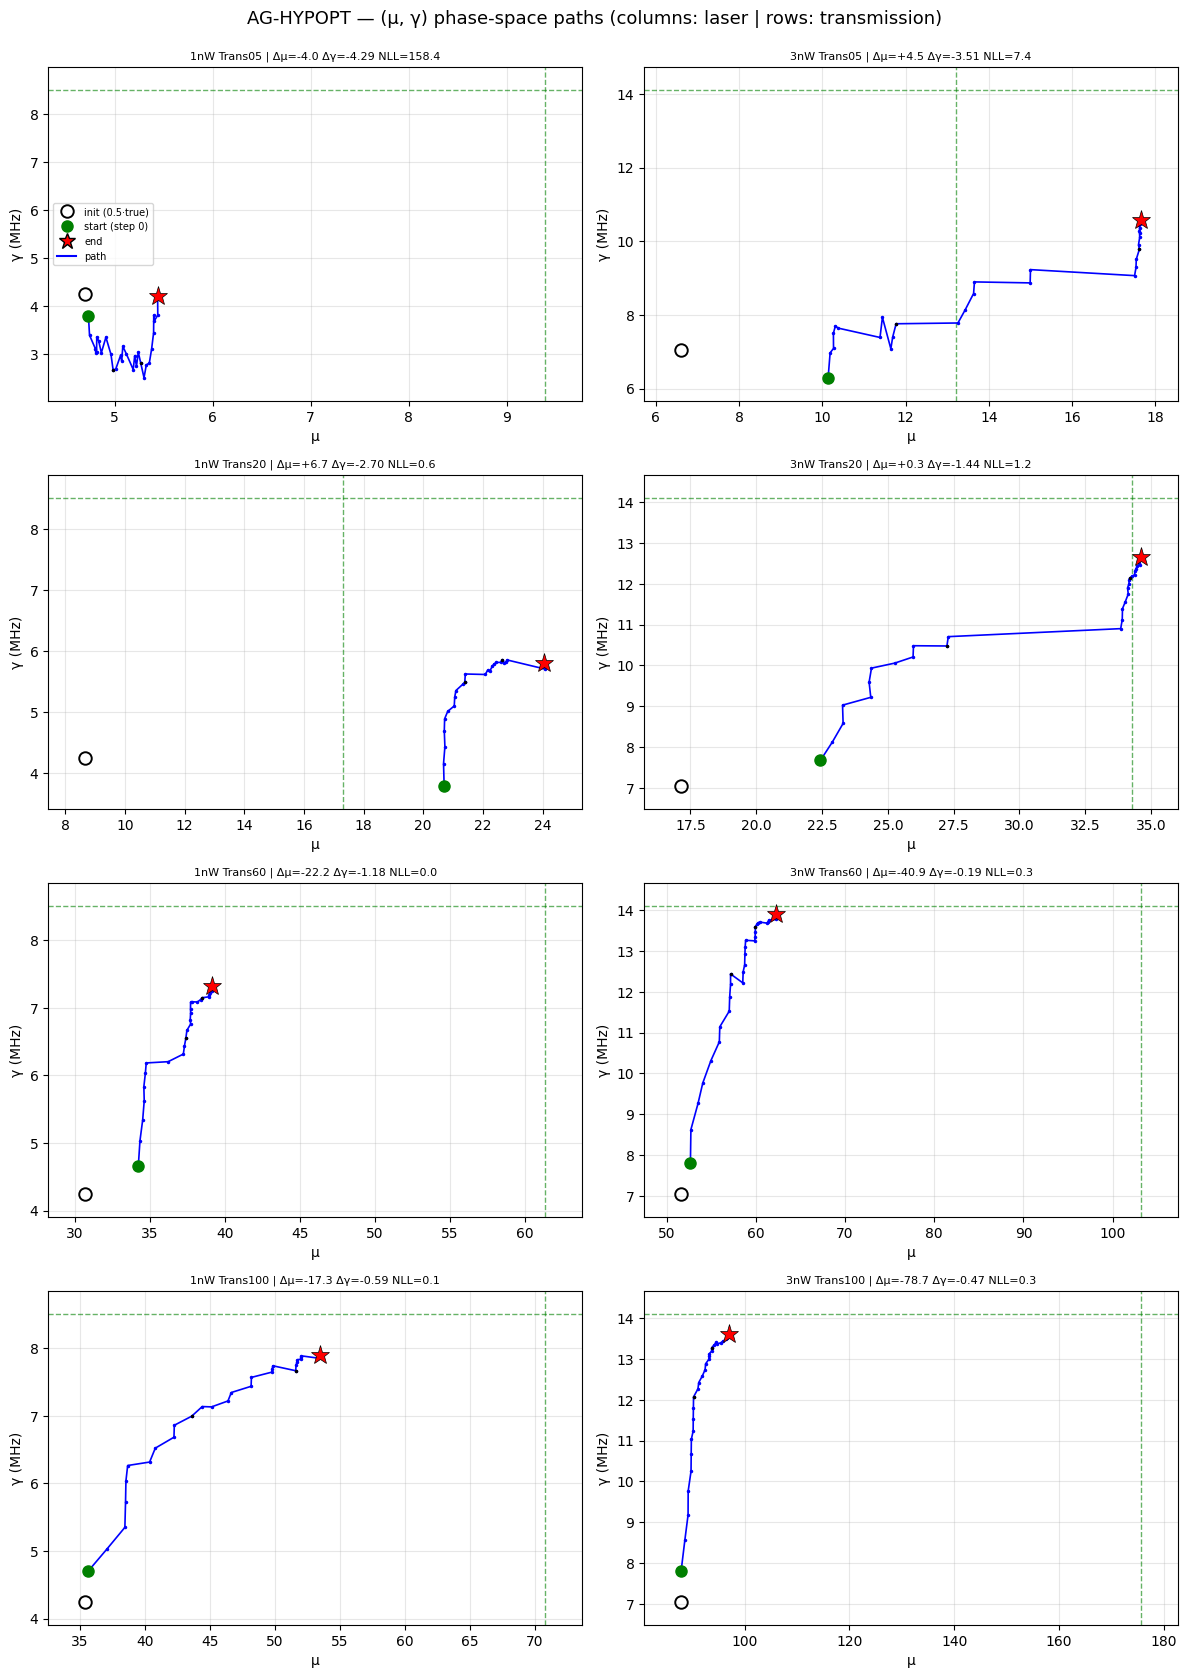

trial finished in 7.8 min
objective = 0.0798 ± 0.0206
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.44   -42.1 |     8.50    4.21   -50.4
1nW Trans20       17.32   24.06   +38.9 |     8.50    5.80   -31.7
1nW Trans60       61.37   39.16   -36.2 |     8.50    7.32   -13.9
1nW Trans100       70.82   53.50   -24.5 |     8.50    7.91    -7.0
3nW Trans05       13.20   17.67   +33.8 |    14.10   10.59   -24.9
3nW Trans20       34.28   34.63    +1.0 |    14.10   12.66   -10.2
3nW Trans60      103.20   62.29   -39.6 |    14.10   13.91    -1.4
3nW Trans100      175.71   97.01   -44.8 |    14.10   13.63    -3.3

weighted objective (T-graded, cap=1.0) = 0.0798 | diverged cells: 0
μ: RMSE 33.057 (rel 35.2%, bias -18.944) | γ: RMSE 2.293 (rel 23.8%, bias -1.797)


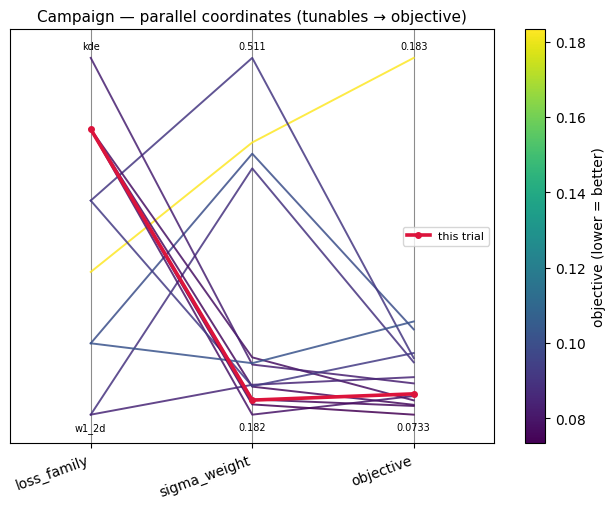

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

**Facts.** Chosen config `{loss_family: 'cvm_fwhm', sigma_weight: 0.1950}` (candidate 5, top EI).
Trial time 7.8 min, objective **0.0798 +/- 0.0206**, **0 diverged cells**. This is a fresh-seed replication
at essentially the same sw as trial_11 (0.1956 -> 0.0760) and yet lands 0.0038 higher - so within the flat
basin the trial-to-trial scatter (~0.004) dominates any residual sw dependence.

**The basin, updated.** All six `cvm_fwhm` points now read 0.0733, 0.0760, 0.0764, 0.0777, 0.0791, 0.0798
(sw 0.1816-0.2345): mean ~0.0771, all at or **just** under the KDE control (0.080328). So the family's
edge over the control is real but modest - about 0.003 on the mean, not the 0.007 implied by the single
best point.

**Per-cell behaviour.** Low-count cells unchanged (1nW Trans05 identical at mu 5.44 / gamma 4.21), 1nW
Trans20 mu +38.9 % / gamma -31.7 %; high-T mu -24.5 to -44.8 %; gamma healthy throughout (only 1nW
Trans05 -50.4 % is badly off).

**Aggregates.** mu: RMSE 33.06 (rel 35.2 %), bias -18.94; gamma: RMSE 2.29 (rel 23.8 %), bias -1.80.

**Summary:** `cvm_fwhm` at sw 0.1950 gives 0.0798 - a near-identical sw to trial_11 (0.0760), showing the
basin's seed scatter is ~0.004; the family sits at ~0.077 on average, just under the KDE control.
**Key insight:** Within the flat `cvm_fwhm` basin the sw dependence is smaller than the seed scatter, so
the honest statement is that `cvm_fwhm` beats the control by a small (~0.003) but consistent margin.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: the ~0.003 margin over the control is small relative to a single-trial uncertainty of
~0.02, so the held-out validation is what really decides whether `cvm_fwhm` is a genuine win.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'cvm_fwhm at sigma_weight 0.1950 gives 0.0798, near-identical sw to trial_11 (0.0760), showing the basin seed scatter is ~0.004; the family sits at ~0.077 on average, just under the KDE control.'      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = 'Within the flat cvm_fwhm basin the sw dependence is smaller than the seed scatter, so cvm_fwhm beats the control by a small (~0.003) but consistent margin.'  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_14 | current best: trial_13


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_15.ipynb. Open it and follow its cells from the top.
